In [34]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib_venn import venn3

In [6]:
#Loading the model and Task 1 data 
model = joblib.load("baseline_rf.joblib")

f5_train = pd.read_csv("f5_train.csv")
f5_test  = pd.read_csv("f5_test.csv")

## Finding optimum threshold based on pr-auc (using f1)

In [7]:
feature_cols = [c for c in f5_train.columns if c not in ["transcript_id", "transcript_position", "label"]]
X_test = f5_test[feature_cols]
y_test = f5_test["label"].astype(int)

# Predict probabilities on test split 
y_prob = model.predict_proba(X_test)[:, 1]

# Best F1 threshold 
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Threshold selection based on Task 1")
print(f"PR-AUC:            {pr_auc:.4f}")
print(f"Best F1:           {f1_scores[best_idx]:.4f}")
print(f"Optimal threshold: {best_threshold:.6f}")

Threshold selection based on Task 1
PR-AUC:            0.3501
Best F1:           0.4234
Optimal threshold: 0.220000


In [8]:
BEST_T = 0.22  

cell_lines = ["A549", "HCT", "HEP2", "K562", "MC67"]
pred_folder = "predictions_task2"  

summary_rows = []

for name in cell_lines:
    path = f"{pred_folder}/{name}_predictions.csv"
    df = pd.read_csv(path)
    df["pred_label"] = (df["score"] >= BEST_T).astype(int)
    
    n_total = len(df)
    n_mod   = int(df["pred_label"].sum())
    frac    = n_mod / n_total if n_total else 0.0
    summary_rows.append([name, n_total, n_mod, frac])

summary = pd.DataFrame(summary_rows, columns=["Cell_Line", "Total_Sites", "Pred_Modified", "Fraction_Modified"])
print("Task 2: counts using Task 1-optimized threshold")
print(summary)

Task 2: counts using Task 1-optimized threshold
  Cell_Line  Total_Sites  Pred_Modified  Fraction_Modified
0      A549       100000           1278            0.01278
1       HCT       100000           1653            0.01653
2      HEP2       100000           1579            0.01579
3      K562       100000           1410            0.01410
4      MC67       100000           1412            0.01412


## Feature Importance plot 

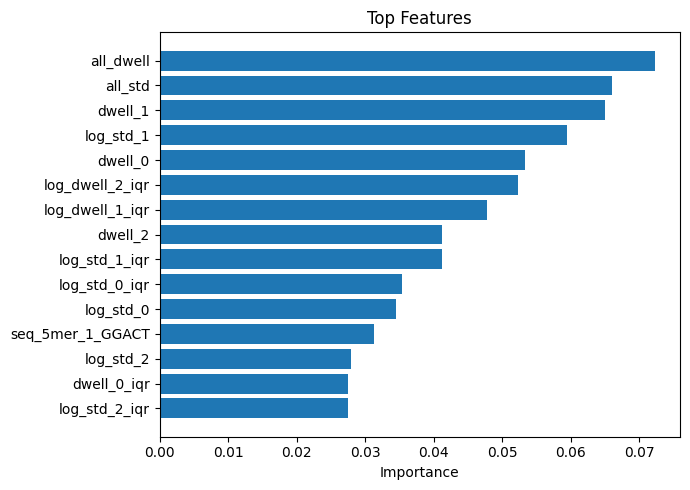

In [12]:
model = joblib.load("baseline_rf.joblib")
importances = model.feature_importances_
feat_names = feature_cols  # from earlier
top_idx = np.argsort(importances)[-15:][::-1]

plt.figure(figsize=(7,5))
plt.barh(range(len(top_idx)), importances[top_idx][::-1])
plt.yticks(range(len(top_idx)), [feat_names[i] for i in top_idx][::-1])
plt.xlabel("Importance")
plt.title("Top Features")
plt.tight_layout()
plt.show()


From the feature importance plot, it’s clear that the model relies heavily on signal-based features like all_dwell, all_std, and log_std_1. These represent how much the nanopore current and dwell time fluctuate near potential m⁶A sites. In contrast, sequence-based features such as the 5-mer motif GGACT contribute less. This suggests that the model is picking up on differences in the electrical signal caused by methylation rather than depending mainly on sequence context, which makes sense since m⁶A modifications often affect the local signal pattern more than the nucleotide sequence itself.

## Correlation plot on the top 5 features 

A549: merged 100000 rows successfully
HCT: merged 100000 rows successfully
HEP2: merged 100000 rows successfully
K562: merged 100000 rows successfully
MC67: merged 100000 rows successfully


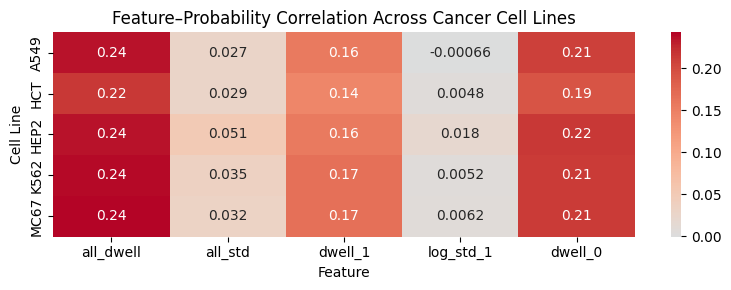

In [27]:
cell_lines = {
    "A549": "a549",
    "HCT": "hct",
    "HEP2": "hep2",
    "K562": "k562",
    "MC67": "mc67"   
}

# Top 5 important features
top5_features = ["all_dwell", "all_std", "dwell_1", "log_std_1", "dwell_0"]

# Store correlations for each cell line
corrs_all = {}

for name, prefix in cell_lines.items():
    try:
        preds = pd.read_csv(f"predictions_task2/{name}_predictions.csv")
        features = pd.read_csv(f"preprocessed_{prefix}.csv")

        
        df = pd.merge(preds, features, on=["transcript_id", "transcript_position"], how="inner")

        
        corrs = df[top5_features + ["score"]].corr()["score"].drop("score")
        corrs_all[name] = corrs

        print(f"{name}: merged {len(df)} rows successfully")
    except Exception as e:
        print(f"⚠️ Skipped {name}: {e}")


corr_df = pd.DataFrame(corrs_all).T

# Plot heatmap
plt.figure(figsize=(8, 3))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0)
plt.title("Feature–Probability Correlation Across Cancer Cell Lines")
plt.xlabel("Feature")
plt.ylabel("Cell Line")
plt.tight_layout()
plt.show()



The correlation plot shows that features related to dwell time (all_dwell, dwell_1, and dwell_0) are consistently the strongest indicators of m⁶A methylation probability across all five cancer cell lines. Sites with longer dwell times generally receive higher predicted m6A scores, suggesting a clear link between slowed RNA translocation through the nanopore and the presence of m⁶A modifications. 

In contrast, features capturing signal variability (all_std, log_std_1) show weaker correlations, meaning they contribute less directly to predicting modification probability. The consistent correlation patterns across A549, HCT, HEP2, K562, and MC67 imply that the model relies on a common physical signal signature of m6A, even though each cell line has a distinct set of modified sites.

## Plot for overlap of m6A sites 

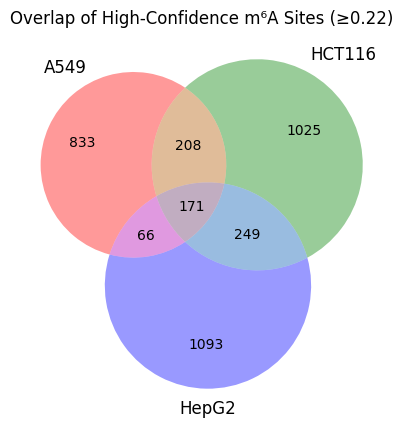

In [13]:
top_sets = {}
for name in ["A549", "HCT", "HEP2"]:
    df = pd.read_csv(f"predictions_task2/{name}_predictions.csv")
    high = df[df["score"] >= 0.22]  # use your threshold
    top_sets[name] = set(zip(high["transcript_id"], high["transcript_position"]))

plt.figure(figsize=(5,5))
venn3([top_sets["A549"], top_sets["HCT"], top_sets["HEP2"]],
      set_labels=("A549","HCT116","HepG2"))
plt.title("Overlap of High-Confidence m⁶A Sites (≥0.22)")
plt.show()


The Venn diagram shows that while a small group of m6A sites is conserved across all cell lines, most are unique to each. This supports the idea that m⁶A methylation patterns are largely cell-type-specific, reflecting differences in transcriptome regulation among these cancers.

## Correlation of predicted probabilities between the 5 cancer cell lines 

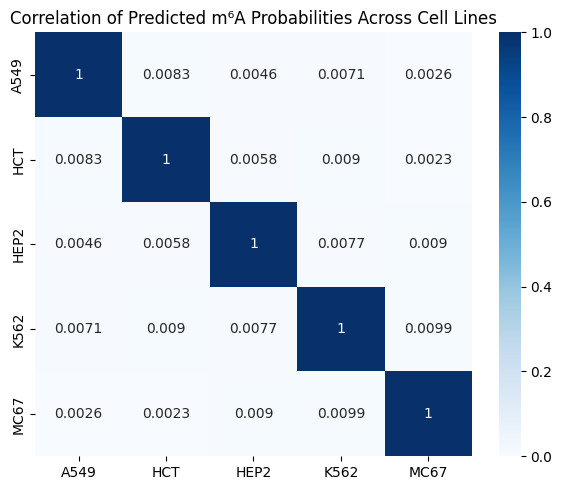

In [19]:
dfs = {name: pd.read_csv(f"predictions_task2/{name}_predictions.csv")["score"]
       for name in ["A549", "HCT", "HEP2", "K562", "MC67"]}

df_corr = pd.DataFrame(dfs).corr()

plt.figure(figsize=(6,5))
sns.heatmap(df_corr, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Correlation of Predicted m⁶A Probabilities Across Cell Lines")
plt.tight_layout()
plt.show()


The correlation heatmap compares the predicted m⁶A modification probabilities across the five cancer cell lines and shows almost no correlation between them. The off-diagonal correlation values are close to zero, indicating that each cell line exhibits a largely distinct pattern of predicted m⁶A sites. 

This suggests that m⁶A modifications are highly cell-type-specific, with each line showing its own characteristic methylation landscape. Biologically, this could reflect differences in gene expression profiles, regulatory mechanisms, and the roles of m⁶A in supporting the unique metabolic or developmental programs of each cancer. 

## Finding transcript ids of with modified sites in 2 or more cancer cell lines

In [36]:
THRESHOLD = 0.22

# exact filenames
cells = {
    "A549": "A549_predictions.csv",
    "HCT": "HCT_predictions.csv",
    "HEP2": "HEP2_predictions.csv",
    "K562": "K562_predictions.csv",
    "MC67": "MC67_predictions.csv"
}

# store top transcripts
top_transcripts = {}

for name, file in cells.items():
    df = pd.read_csv(f"predictions_task2/{file}")
    
    # aggregate by transcript
    agg = (
        df.groupby("transcript_id")
          .agg(
              site_count=("score", lambda x: (x >= THRESHOLD).sum()),
              mean_score=("score", "mean")
          )
          .reset_index()
    )
    
    # filter and select top 20
    top20 = agg[agg["site_count"] > 0].sort_values("site_count", ascending=False).head(20)
    top_transcripts[name] = set(top20["transcript_id"])

# combine to find overlaps
transcript_sources = defaultdict(list)

for cell, transcripts in top_transcripts.items():
    for t in transcripts:
        transcript_sources[t].append(cell)

# keep only transcripts appearing in 2 or more cell lines
multi_line_transcripts = {
    t: sorted(lines) for t, lines in transcript_sources.items() if len(lines) >= 2
}

# convert to DataFrame for display 
result_df = pd.DataFrame([
    {"Transcript_ID": t, "Cell_Lines": ", ".join(lines), "Count": len(lines)}
    for t, lines in multi_line_transcripts.items()
]).sort_values("Count", ascending=False)

print("Transcripts Appearing in ≥2 Cell Lines")
print(result_df if not result_df.empty else "None found")

Transcripts Appearing in ≥2 Cell Lines
      Transcript_ID        Cell_Lines  Count
0   ENST00000312579   A549, HCT, K562      3
5   ENST00000299238   A549, HCT, HEP2      3
14  ENST00000519077   HCT, HEP2, K562      3
8   ENST00000355527  A549, HEP2, K562      3
7   ENST00000429989   A549, HCT, HEP2      3
6   ENST00000359591   A549, HCT, K562      3
1   ENST00000542575        A549, K562      2
4   ENST00000335793        A549, K562      2
2   ENST00000372491         A549, HCT      2
3   ENST00000291442        A549, K562      2
9   ENST00000300087         HCT, HEP2      2
10  ENST00000304658         HCT, HEP2      2
12  ENST00000321407         HCT, HEP2      2
11  ENST00000267984         HCT, HEP2      2
13  ENST00000297689         HCT, K562      2
15  ENST00000234256        HEP2, K562      2
16  ENST00000590740        HEP2, K562      2
17  ENST00000377245        HEP2, K562      2


The table lists transcripts that occur in the top 20 most predicted m6A-modified RNAs across multiple cancer cell lines. Transcripts appearing in three or more lines (e.g., ENST00000312579, ENST00000299238) represent conserved m6A-rich genes that may play essential regulatory roles shared across cancers. 

Those found in only two lines likely reflect partially overlapping, tissue-specific methylation programs. Overall, this overlap analysis suggests that while m6A modification landscapes are mostly cell-type-specific, a subset of transcripts shows consistent methylation across cancers, pointing to a possible core set of m6A-regulated genes.